In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv(
    "central_80_discount.csv",
    header=None,
    names=["order_id", "sub_category", "region", "sales", "profit", "discount", "quantity"]
)

In [17]:
df.head()

,order_id,sub_category,region,sales,profit,discount,quantity
0,US-2024-105613,Appliances,Central,73.16,-186.57,0.8,6
1,US-2026-147207,Appliances,Central,5.43,-13.58,0.8,2
2,US-2026-115651,Appliances,Central,58.46,-146.16,0.8,9
3,US-2026-118773,Appliances,Central,12.99,-32.48,0.8,2
4,US-2023-129189,Appliances,Central,4.99,-12.98,0.8,3


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      301 non-null    str    
 1   sub_category  301 non-null    str    
 2   region        301 non-null    str    
 3   sales         301 non-null    float64
 4   profit        301 non-null    float64
 5   discount      301 non-null    float64
 6   quantity      301 non-null    int64  
dtypes: float64(3), int64(1), str(3)
memory usage: 16.6 KB


In [19]:
df[["sales", "profit"]].sum()

sales     16980.07
profit   -30565.36
dtype: float64

In [20]:
df["original_sales"] = df["sales"] / (1 - df["discount"])

In [21]:
df[["sales", "discount", "original_sales"]].head()

,sales,discount,original_sales
0,73.16,0.8,365.80
1,5.43,0.8,27.15
2,58.46,0.8,292.30
3,12.99,0.8,64.95
4,4.99,0.8,24.95


In [22]:
df["cost"] = df["sales"] - df["profit"]

In [23]:
df[["sales", "profit", "cost"]].head()

,sales,profit,cost
0,73.16,-186.57,259.73
1,5.43,-13.58,19.01
2,58.46,-146.16,204.62
3,12.99,-32.48,45.47
4,4.99,-12.98,17.97


In [24]:
scenario_discount=0.5
df["scenario_sales"]=df["original_sales"]*(1-scenario_discount)
df["scenario_profit"]=df["scenario_sales"]-df["cost"]
df[["sales", "profit", "original_sales", "cost", "scenario_sales", "scenario_profit"]].head()



,sales,profit,original_sales,cost,scenario_sales,scenario_profit
0,73.16,-186.57,365.80,259.73,182.900,-76.830
1,5.43,-13.58,27.15,19.01,13.575,-5.435
2,58.46,-146.16,292.30,204.62,146.150,-58.470
3,12.99,-32.48,64.95,45.47,32.475,-12.995
4,4.99,-12.98,24.95,17.97,12.475,-5.495


In [25]:
df["scenario_profit"].sum()

np.float64(-5095.254999999991)

In [26]:
#Calculating the hypothetical profit and profit margin if sold at different discount rates
discounts = [0.8, 0.7, 0.6, 0.5, 0.4]
for discount in discounts:
    scenario_sales = df["original_sales"] * (1 - discount)
    scenario_profit = scenario_sales - df["cost"]
    scenario_margin = scenario_profit.sum() / scenario_sales.sum() * 100
    
    print(
        f"{discount:.0%} discount: "
        f"${scenario_profit.sum():,.2f} profit | "
        f"{scenario_margin:.1f}% margin"
    )

#Scenario analysis: Central's 80%-discount transactions generated an estimated $30.6k loss and a -180% profit margin. Assuming the same transactions and costs, reducing the discount to 40% would have resulted in an estimated $3.4k profit and a 6.7% margin — a potential $34.0k improvement.

80% discount: $-30,565.36 profit | -180.0% margin
70% discount: $-22,075.32 profit | -86.7% margin
60% discount: $-13,585.29 profit | -40.0% margin
50% discount: $-5,095.25 profit | -12.0% margin
40% discount: $3,394.78 profit | 6.7% margin


In [27]:
results = []

for discount in discounts:
    scenario_sales = df["original_sales"] * (1 - discount)
    scenario_profit = scenario_sales - df["cost"]
    total_sales = scenario_sales.sum()
    total_profit = scenario_profit.sum()
    profit_margin = total_profit / total_sales * 100
    
    results.append({
        "Discount": discount,
        "Sales": total_sales,
        "Profit": total_profit,
        "Profit Margin": profit_margin
    })

results_df = pd.DataFrame(results)

results_df

,Discount,Sales,Profit,Profit Margin
0,0.8,16980.070,-30565.360,-180.007267
1,0.7,25470.105,-22075.325,-86.671512
2,0.6,33960.140,-13585.290,-40.003634
3,0.5,42450.175,-5095.255,-12.002907
4,0.4,50940.210,3394.780,6.664244


In [ ]:
central_sales = 503170.66
central_profit = 39865.40

actual_80_sales = df["sales"].sum()
actual_80_profit = df["profit"].sum()

results_df["Central Sales"] = (
    central_sales - actual_80_sales + results_df["Sales"]
)

results_df["Central Profit"] = (
    central_profit - actual_80_profit + results_df["Profit"]
)

results_df["Central Profit Margin"] = (
    results_df["Central Profit"] / results_df["Central Sales"] * 100
)

results_df

#If the same transactions currently sold at an 80% discount had instead been sold at 40%, Central's overall profit margin would have increased from approximately 7.9% to 13.7%, assuming sales volume remained unchanged.

,Discount,Sales,Profit,Profit Margin,Central Sales,Central Profit,Central Profit Margin
0,0.8,16980.070,-30565.360,-180.007267,503170.660,39865.400,7.922839
1,0.7,25470.105,-22075.325,-86.671512,511660.695,48355.435,9.450684
2,0.6,33960.140,-13585.290,-40.003634,520150.730,56845.470,10.928653
3,0.5,42450.175,-5095.255,-12.002907,528640.765,65335.505,12.359150
4,0.4,50940.210,3394.780,6.664244,537130.800,73825.540,13.744425


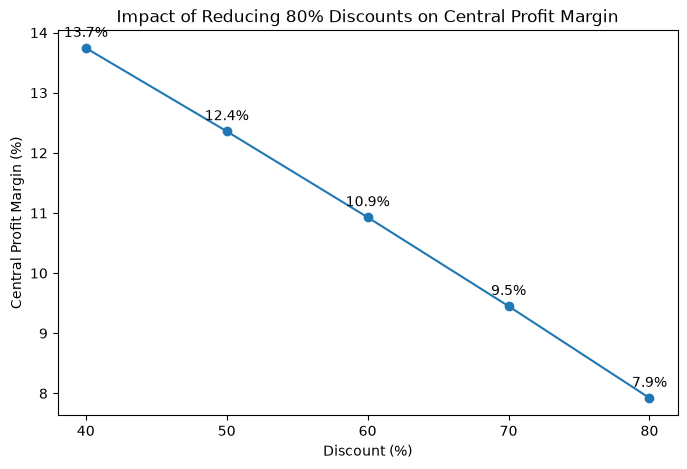

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Discount"] * 100,
    results_df["Central Profit Margin"],
    marker="o"
)

for x, y in zip(
    results_df["Discount"] * 100,
    results_df["Central Profit Margin"]
):
    plt.annotate(
        f"{y:.1f}%",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

plt.xlabel("Discount (%)")
plt.ylabel("Central Profit Margin (%)")
plt.title("Impact of Reducing 80% Discounts on Central Profit Margin")

plt.xticks([40, 50, 60, 70, 80])

plt.show()